In [2]:
%matplotlib inline
import json
import os
from datetime import datetime, timedelta
import pyarrow as pa
import pyarrow.parquet as pq
import scrython
from scrython.base import ScrythonRequestHandler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

app_name = "EDHDataAnalysis"
app_email = "avivg2001@gmail.com"
path_cards_file = "cards.json"
path_cards_parquet = "cards.parquet"
path_scryfall_fields = "scryfall_fields.json"

## Fetch Data

In [3]:
def fetch_cards() -> pd.DataFrame:
    ScrythonRequestHandler.set_user_agent(f'{app_name}/1.0 ({app_email})')
    bulk = scrython.bulk_data.ByType(type='oracle_cards')
    download_url = bulk.download_uri

    import requests
    headers = {'User-Agent': f'{app_name}/1.0 ({app_email})'}
    with requests.get(download_url, headers=headers, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        with open(path_cards_file, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc='Downloading') as bar:
            for chunk in r.iter_content(chunk_size=1024 * 256):
                f.write(chunk)
                bar.update(len(chunk))

    df = clean_cards_df(pd.read_json(path_cards_file))
    table = pa.Table.from_pandas(df)
    merged_meta = {
        **(table.schema.metadata or {}),
        b'fetch_date': datetime.now().isoformat().encode(),
    }
    pq.write_table(table.replace_schema_metadata(merged_meta), path_cards_parquet)

    with open(path_scryfall_fields, 'w') as f:
        json.dump(list(df.columns), f, indent=2)

    return df

## Preprocess Data

In [4]:
WUBRG_ORDER = {c: i for i, c in enumerate('WUBRG')}

def clean_cards_df(df: pd.DataFrame) -> pd.DataFrame:
    df = scryfall_set_field_types(df)
    df = scryfall_filter_out_rows(df)

    return df

def scryfall_set_field_types(df: pd.DataFrame) -> pd.DataFrame:
    df['released_at'] = pd.to_datetime(df['released_at'], errors='coerce')

    # power/toughness can be "*" or "1+*" — coerce non-numeric to NaN
    numeric_cols = [
        'power', 'toughness', 'cmc', 'edhrec_rank', 'collector_number',
        'mtgo_id', 'mtgo_foil_id', 'tcgplayer_id', 'cardmarket_id',
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'prices' in df.columns:
        prices = pd.json_normalize(df['prices'].tolist())
        prices.index = df.index
        for col in prices.columns:
            df[f'price_{col}'] = pd.to_numeric(prices[col], errors='coerce')
        df = df.drop(columns=['prices'])

    if 'legalities' in df.columns:
        legalities = pd.json_normalize(df['legalities'].tolist())
        legalities.index = df.index
        for col in legalities.columns:
            df[f'legal_{col}'] = legalities[col] == 'legal'
        df = df.drop(columns=['legalities'])

    _wubrg_sort = lambda c: sorted(c, key=lambda x: WUBRG_ORDER.get(x, 99))
    for col in ('color_identity', 'colors'):
        if col in df.columns:
            df[col] = df[col].map(_wubrg_sort, na_action='ignore')

    categorical_cols = ['rarity', 'layout', 'set_type', 'border_color', 'frame', 'lang', 'image_status']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    bool_cols = [
        'reserved', 'game_changer', 'foil', 'nonfoil', 'oversized', 'promo',
        'reprint', 'variation', 'digital', 'full_art', 'textless', 'booster',
        'story_spotlight', 'highres_image',
    ]
    for col in bool_cols:
        if col in df.columns:
            df[col] = df[col].astype('boolean')

    return df

def scryfall_filter_out_rows(df: pd.DataFrame) -> pd.DataFrame:
    if 'legal_commander' in df.columns and 'games' in df.columns:
        df = df[df['legal_commander'] & df['games'].apply(lambda x: 'paper' in x)]

    return df

def _expected_parquet_columns() -> frozenset | None:
    if not os.path.exists(path_scryfall_fields):
        return None
    with open(path_scryfall_fields) as f:
        return frozenset(json.load(f))

## Load Dataframe

In [5]:
def load_cards_df() -> pd.DataFrame:
    fetch_date = None
    schema_ok = False

    if os.path.exists(path_cards_parquet):
        parquet_cols = frozenset(pq.read_schema(path_cards_parquet).names)
        schema_ok = parquet_cols == _expected_parquet_columns()
        meta = pq.read_metadata(path_cards_parquet).metadata or {}
        fetch_date_str = meta.get(b'fetch_date', b'').decode()
        if fetch_date_str:
            fetch_date = datetime.fromisoformat(fetch_date_str)

    stale = fetch_date is None or (datetime.now() - fetch_date) >= timedelta(weeks=2)

    if schema_ok and not stale:
        return pd.read_parquet(path_cards_parquet)

    return fetch_cards()

cards_df = load_cards_df()

# One-time: re-save parquet with WUBRG-sorted color_identity and colors
_wubrg_sort = lambda c: sorted(c, key=lambda x: WUBRG_ORDER.get(x, 99))
for _col in ('color_identity', 'colors'):
    if _col in cards_df.columns:
        cards_df[_col] = cards_df[_col].map(_wubrg_sort, na_action='ignore')
table = pa.Table.from_pandas(cards_df)
meta = pq.read_metadata(path_cards_parquet).metadata or {}
pq.write_table(table.replace_schema_metadata(meta), path_cards_parquet)

Downloading: 0.00B [00:00, ?B/s]

Downloading: 5.14MB [00:00, 38.8MB/s]

Downloading: 12.9MB [00:00, 47.1MB/s]

Downloading: 19.5MB [00:00, 54.3MB/s]

Downloading: 25.2MB [00:00, 52.1MB/s]

...

Downloading: 149MB [00:02, 51.0MB/s]

Downloading: 157MB [00:02, 51.9MB/s]

Downloading: 162MB [00:03, 52.2MB/s]

Downloading: 168MB [00:03, 54.9MB/s]

Downloading: 174MB [00:03, 53.7MB/s]

# Data Validation

## Overview

In [5]:
OVERVIEW_COLS = [
    'name', 'cmc', 'color_identity', 'mana_cost', 'type_line', 'set',
    'oracle_text', 'power', 'toughness', 'edhrec_rank', 'produced_mana',
    'game_changer', 'price_usd', 'legal_commander',
]

def print_df_stats(df: pd.DataFrame) -> None:
    print(f"Cards: {len(df):,}")
    print(f"Fields: {len(df.columns)}\n")

    cols = [c for c in OVERVIEW_COLS if c in df.columns]
    col_width = max(len(c) for c in cols)
    for col in cols:
        dtype = str(df[col].dtype)
        null_pct = df[col].isna().mean() * 100
        filled_pct = 100 - null_pct
        print(f"  {col:<{col_width}}  {dtype:<12}  {filled_pct:5.1f}% filled")
    
print_df_stats(cards_df)

Cards: 29,919
Fields: 113

  name             str           100.0% filled
  cmc              float64       100.0% filled
  color_identity   object        100.0% filled
  mana_cost        str            98.4% filled
  type_line        str           100.0% filled
  set              str           100.0% filled
  oracle_text      str            97.3% filled
  power            float64        54.4% filled
  toughness        float64        54.5% filled
  edhrec_rank      float64        99.8% filled
  produced_mana    object          7.8% filled
  game_changer     boolean       100.0% filled
  price_usd        float64        99.1% filled
  legal_commander  bool          100.0% filled


In [6]:
def print_missing_examples(df: pd.DataFrame, n: int = 5) -> None:
    cols = [c for c in OVERVIEW_COLS if c in df.columns]
    for col in cols:
        missing = df[df[col].isna()]
        if missing.empty:
            continue
        print(f"{'=' * 55}")
        print(f"  {col} — {len(missing):,} missing ({len(missing)/len(df)*100:.1f}%)")
        print(f"{'=' * 55}")
        display_cols = ['name', 'type_line', col] if col != 'name' else ['name', 'type_line']
        print(missing[display_cols].head(n).to_string(index=False))
        print()

print_missing_examples(cards_df)

  mana_cost — 481 missing (1.6%)
                                               name                                                                          type_line mana_cost
         Ulvenwald Captive // Ulvenwald Abomination                          Creature — Werewolf Horror // Creature — Eldrazi Werewolf       NaN
    Azusa's Many Journeys // Likeness of the Seeker                            Enchantment — Saga // Enchantment Creature — Human Monk       NaN
            Witch Enchanter // Witch-Blessed Meadow                                                   Creature — Human Warlock // Land       NaN
The Emperor of Palamecia // The Lord Master of Hell Legendary Creature — Human Noble Wizard // Legendary Creature — Demon Noble Wizard       NaN
        Westvale Abbey // Ormendahl, Profane Prince                                                 Land // Legendary Creature — Demon       NaN

  oracle_text — 803 missing (2.7%)
                                           name              

In [7]:
import json

check_names_mana = [
    'Ulvenwald Captive // Ulvenwald Abomination',
    'Azusa\'s Many Journeys // Likeness of the Seeker',
    'Witch Enchanter // Witch-Blessed Meadow',
    'The Emperor of Palamecia // The Lord Master of Hell',
    'Westvale Abbey // Ormendahl, Profane Prince',
]
check_names_edhrec = ['Wastes']

with open(path_cards_file, encoding='utf-8') as f:
    raw = json.load(f)

raw_df = pd.DataFrame(raw)

print("=== mana_cost / oracle_text from raw JSON ===")
cols = ['name', 'mana_cost', 'oracle_text']
res = raw_df[raw_df['name'].isin(check_names_mana)][cols]
for _, row in res.iterrows():
    print(f"\n  {row['name']}")
    print(f"    mana_cost:   {repr(row['mana_cost'])}")
    print(f"    oracle_text: {repr(str(row['oracle_text'])[:120])}")

print("\n=== edhrec_rank for basic lands from raw JSON ===")
basic_lands = raw_df[raw_df['type_line'].str.contains('Basic Land', na=False)][['name', 'edhrec_rank']].drop_duplicates('name')
print(basic_lands.to_string(index=False))

=== mana_cost / oracle_text from raw JSON ===

  Ulvenwald Captive // Ulvenwald Abomination
    mana_cost:   nan
    oracle_text: 'nan'

  Azusa's Many Journeys // Likeness of the Seeker
    mana_cost:   nan
    oracle_text: 'nan'

  Witch Enchanter // Witch-Blessed Meadow
    mana_cost:   nan
    oracle_text: 'nan'

  The Emperor of Palamecia // The Lord Master of Hell
    mana_cost:   nan
    oracle_text: 'nan'

  Westvale Abbey // Ormendahl, Profane Prince
    mana_cost:   nan
    oracle_text: 'nan'

=== edhrec_rank for basic lands from raw JSON ===
        name  edhrec_rank
      Wastes          NaN
Barry's Land          NaN
       Swamp          NaN
    Mountain          NaN
      Island          NaN
      Forest          NaN
      Plains          NaN


In [8]:
def print_top_edhrec(df: pd.DataFrame, n: int = 10) -> None:
    top = (df.dropna(subset=['edhrec_rank'])
             .sort_values('edhrec_rank')
             .head(n)[['name', 'edhrec_rank', 'type_line', 'cmc']])
    print(top.to_string(index=False))

print_top_edhrec(cards_df)

                name  edhrec_rank            type_line  cmc
            Sol Ring          1.0             Artifact  1.0
       Command Tower          2.0                 Land  0.0
       Arcane Signet          3.0             Artifact  2.0
      Exotic Orchard          9.0                 Land  0.0
     Reliquary Tower         10.0                 Land  0.0
Swords to Plowshares         11.0              Instant  1.0
     Swiftfoot Boots         12.0 Artifact — Equipment  2.0
   Lightning Greaves         13.0 Artifact — Equipment  2.0
    Path of Ancestry         14.0                 Land  0.0
       Path to Exile         15.0              Instant  1.0


## CMC Distribution

In [9]:
def plot_cmc_distribution(df: pd.DataFrame, n: int = 1000) -> None:
    top = (df.dropna(subset=['edhrec_rank', 'cmc'])
             .sort_values('edhrec_rank'))
    top['cmc'].value_counts().sort_index().plot(kind='bar')
    plt.title(f'CMC Distribution — Top {n} EDHREC Cards')
    plt.xlabel('CMC')
    plt.ylabel('Card Count')
    plt.tight_layout()
    plt.show()

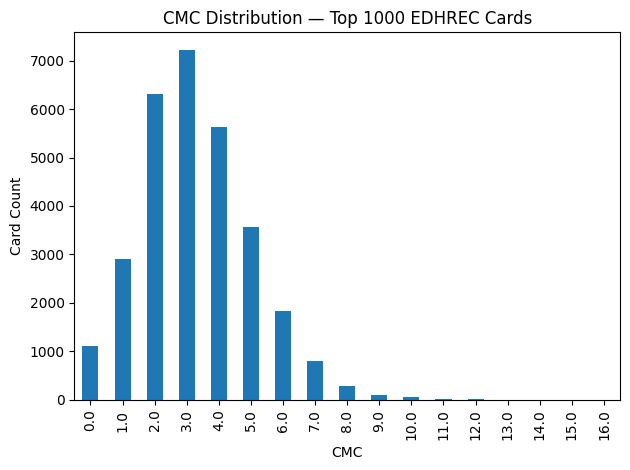

In [10]:
plot_cmc_distribution(cards_df)

## Color Identity Distribution

In [11]:
def plot_color_identity_distribution(df: pd.DataFrame) -> None:
    color_names = {'W': 'White', 'U': 'Blue', 'B': 'Black', 'R': 'Red', 'G': 'Green'}

    def categorize(colors):
        if len(colors) == 0:
            return 'Colorless'
        if len(colors) == 1:
            return color_names[colors[0]]
        return 'Multicolored'

    order = ['White', 'Blue', 'Black', 'Red', 'Green', 'Colorless', 'Multicolored']
    counts = df['color_identity'].apply(categorize).value_counts().reindex(order, fill_value=0)
    counts.plot(kind='bar')
    plt.title('Card Count by Color Identity')
    plt.xlabel('Color')
    plt.ylabel('Card Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

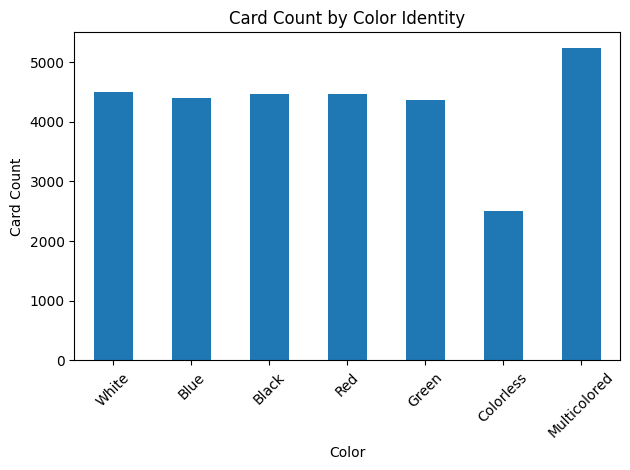

In [12]:
plot_color_identity_distribution(cards_df)

## Card Count by Year

In [13]:
def plot_card_count_by_year(df: pd.DataFrame) -> None:
    year_counts = (
        df.dropna(subset=['released_at'])
          .assign(year=lambda d: d['released_at'].dt.year)
          .groupby('year')
          .size()
          .reset_index(name='count')
    )
    plt.figure(figsize=(12, 5))
    plt.bar(year_counts['year'], year_counts['count'])
    plt.title('Card Count by Year')
    plt.xlabel('Year')
    plt.ylabel('Card Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

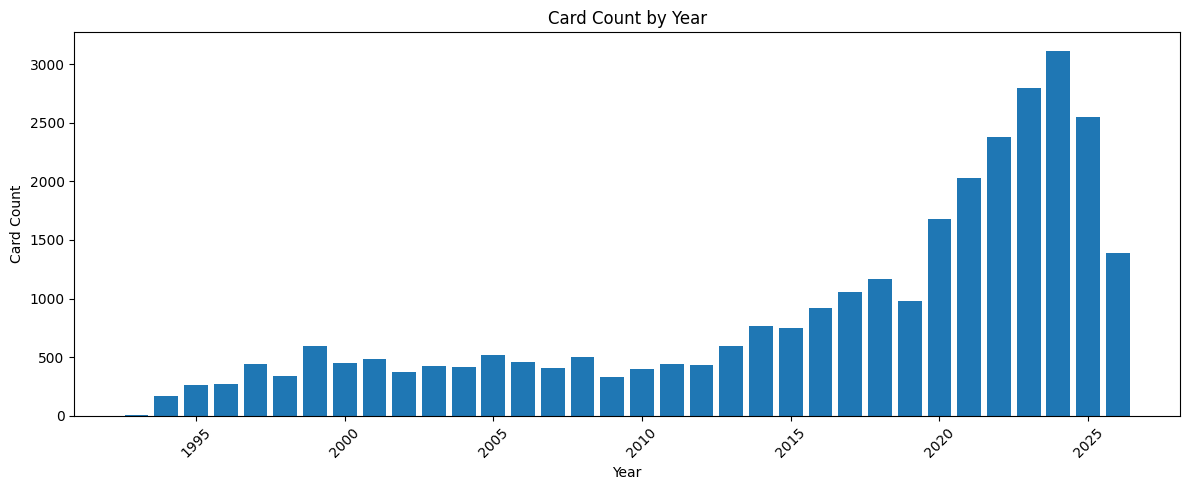

In [14]:
plot_card_count_by_year(cards_df)

# Outliers

## Field Statistics

For each field: mean, std, median, and the 5 highest/lowest cards (subsorted by EDHREC rank).

In [15]:
def print_field_outliers(df: pd.DataFrame, value_col: str, label: str,
                          name_col: str = 'name', rank_col: str = 'edhrec_rank', n: int = 5) -> None:
    s = df.dropna(subset=[value_col, name_col]).copy()

    print(f"{'=' * 55}")
    print(f"  {label}")
    print(f"{'=' * 55}")
    print(f"  Count:  {len(s):,}")
    print(f"  Mean:   {s[value_col].mean():.2f}")
    print(f"  Std:    {s[value_col].std():.2f}")
    print(f"  Median: {s[value_col].median():.2f}")

    # Sort by value, use edhrec_rank as tie-breaker (NaN rank goes last)
    lowest  = s.sort_values([value_col, rank_col], ascending=[True,  True], na_position='last').head(n)
    highest = s.sort_values([value_col, rank_col], ascending=[False, True], na_position='last').head(n)

    display_cols = [name_col, value_col, rank_col]

    print(f"\n  Lowest {n}:")
    print(lowest[display_cols].to_string(index=False))

    print(f"\n  Highest {n}:")
    print(highest[display_cols].to_string(index=False))
    print()

### Name Length

In [16]:
_outlier_df = cards_df.copy()
_outlier_df['name_length'] = _outlier_df['name'].str.len()
_outlier_df['oracle_text_length'] = _outlier_df['oracle_text'].str.len()

print_field_outliers(_outlier_df, 'name_length', 'Name Length')

  Name Length
  Count:  29,919
  Mean:   16.56
  Std:    5.60
  Median: 16.00

  Lowest 5:
name  name_length  edhrec_rank
 Opt            3        214.0
 Six            3        551.0
 Fog            3        720.0
 Hex            3       7131.0
 Fly            3       8948.0

  Highest 5:
                                                         name  name_length  edhrec_rank
Sidequest: Play Blitzball // World Champion, Celestial Weapon           61      11744.0
  Blitzwing, Cruel Tormentor // Blitzwing, Adaptive Assailant           59       8238.0
  Hermit of the Natterknolls // Lone Wolf of the Natterknolls           59      11818.0
   Reidane, God of the Worthy // Valkmira, Protector's Shield           58       6268.0
    Liliana, Heretical Healer // Liliana, Defiant Necromancer           57       4332.0



### CMC

In [17]:
print_field_outliers(_outlier_df, 'cmc', 'CMC (Converted Mana Cost)')

  CMC (Converted Mana Cost)
  Count:  29,919
  Mean:   3.29
  Std:    1.75
  Median: 3.00

  Lowest 5:
            name  cmc  edhrec_rank
   Command Tower  0.0          2.0
  Exotic Orchard  0.0          9.0
 Reliquary Tower  0.0         10.0
Path of Ancestry  0.0         14.0
  Evolving Wilds  0.0         18.0

  Highest 5:
               name  cmc  edhrec_rank
              Draco 16.0       9788.0
  Earthquake Dragon 15.0       3200.0
Shadow of Mortality 15.0       4430.0
    Autochthon Wurm 15.0      19639.0
 Blinkmoth Infusion 14.0      14873.0



### Power

In [18]:
print_field_outliers(_outlier_df, 'power', 'Power')

  Power
  Count:  16,262
  Mean:   2.68
  Std:    1.68
  Median: 2.00

  Lowest 5:
                   name  power  edhrec_rank
        Spinal Parasite   -1.0      25845.0
           Char-Rumbler   -1.0      29170.0
      Birds of Paradise    0.0         33.0
           Blood Artist    0.0        138.0
Ornithopter of Paradise    0.0        227.0

  Highest 5:
                         name  power  edhrec_rank
Dawnsire, Sunstar Dreadnought   20.0       3389.0
           Yargle and Multani   18.0       2943.0
         Impervious Greatwurm   16.0       4302.0
              Worldspine Wurm   15.0       2414.0
    Emrakul, the Promised End   13.0       1833.0



### Toughness

In [19]:
print_field_outliers(_outlier_df, 'toughness', 'Toughness')

  Toughness
  Count:  16,312
  Mean:   2.89
  Std:    1.70
  Median: 3.00

  Lowest 5:
               name  toughness  edhrec_rank
    Spinal Parasite       -1.0      25845.0
Phyrexian Metamorph        0.0        306.0
       Spark Double        0.0        407.0
   Walking Ballista        0.0        454.0
    Faeburrow Elder        0.0        517.0

  Highest 5:
                         name  toughness  edhrec_rank
      The Walls of Ba Sing Se       30.0       2546.0
Dawnsire, Sunstar Dreadnought       20.0       3389.0
          Ancient Adamantoise       20.0       5298.0
      Charix, the Raging Isle       17.0       3618.0
         Impervious Greatwurm       16.0       4302.0



### Oracle Text Length

In [20]:
print_field_outliers(_outlier_df, 'oracle_text_length', 'Oracle Text Length')

  Oracle Text Length
  Count:  29,116
  Mean:   158.97
  Std:    86.41
  Median: 147.00

  Lowest 5:
                 name  oracle_text_length  edhrec_rank
     Phyrexian Walker                 0.0       2911.0
   Yargle and Multani                 0.0       2943.0
        Gigantosaurus                 0.0       4620.0
 Indomitable Ancients                 0.0       4740.0
Quakestrider Ceratops                 0.0       5553.0

  Highest 5:
               name  oracle_text_length  edhrec_rank
 Master of the Hunt               627.0      28582.0
         Camouflage               589.0      25216.0
         Necromancy               554.0        983.0
Tombstone Stairwell               535.0       9567.0
     Roiling Horror               534.0      25830.0



## Top 5 Oldest Cards

In [21]:
def print_oldest_cards(df: pd.DataFrame, n: int = 5) -> None:
    oldest = (df.dropna(subset=['released_at'])
                .sort_values('released_at')
                .head(n)[['name', 'released_at', 'set', 'type_line', 'edhrec_rank']])
    print(f"Top {n} Oldest Cards:")
    print(oldest.to_string(index=False))

print_oldest_cards(cards_df)

Top 5 Oldest Cards:
             name released_at set   type_line  edhrec_rank
       Camouflage  1993-12-01 2ed     Instant      25216.0
     False Orders  1993-12-01 2ed     Instant      23408.0
     Raging River  1993-12-01 2ed Enchantment      19978.0
Natural Selection  1993-12-01 2ed     Instant      27270.0
    Army of Allah  1993-12-17 arn     Instant      27583.0


## Best EDHREC Rank per Color

In [22]:
def print_best_edhrec_per_color(df: pd.DataFrame) -> None:
    s = df.dropna(subset=['edhrec_rank', 'colors']).copy()

    # colors is already in WUBRG order from preprocessing — just join
    s['color_key'] = s['colors'].apply(
        lambda c: ''.join(c) if len(c) > 0 else 'C'
    )

    idx = s.groupby('color_key')['edhrec_rank'].idxmin()
    result = s.loc[idx][['color_key', 'name', 'edhrec_rank', 'type_line', 'cmc']].copy()

    def color_sort_key(key):
        if key == 'C':
            return (0, ())
        return (len(key), tuple(WUBRG_ORDER[c] for c in key))

    result = result.iloc[result['color_key'].map(color_sort_key).argsort()]

    print("Best EDHREC Rank (most popular) per Color:")
    print(result.to_string(index=False))

print_best_edhrec_per_color(cards_df)

Best EDHREC Rank (most popular) per Color:
color_key                      name  edhrec_rank                                   type_line  cmc
        C                  Sol Ring          1.0                                    Artifact  1.0
        W      Swords to Plowshares         11.0                                     Instant  1.0
        U              Counterspell         16.0                                     Instant  2.0
        B               Dark Ritual         34.0                                     Instant  1.0
        R           Blasphemous Act         22.0                                     Sorcery  9.0
        G                 Cultivate         20.0                                     Sorcery  3.0
       WU              Dovin's Veto        250.0                                     Instant  2.0
       WB        Anguished Unmaking        153.0                                     Instant  3.0
       WR               Boros Charm        176.0                           

## Highest Priced Card (USD) per Set

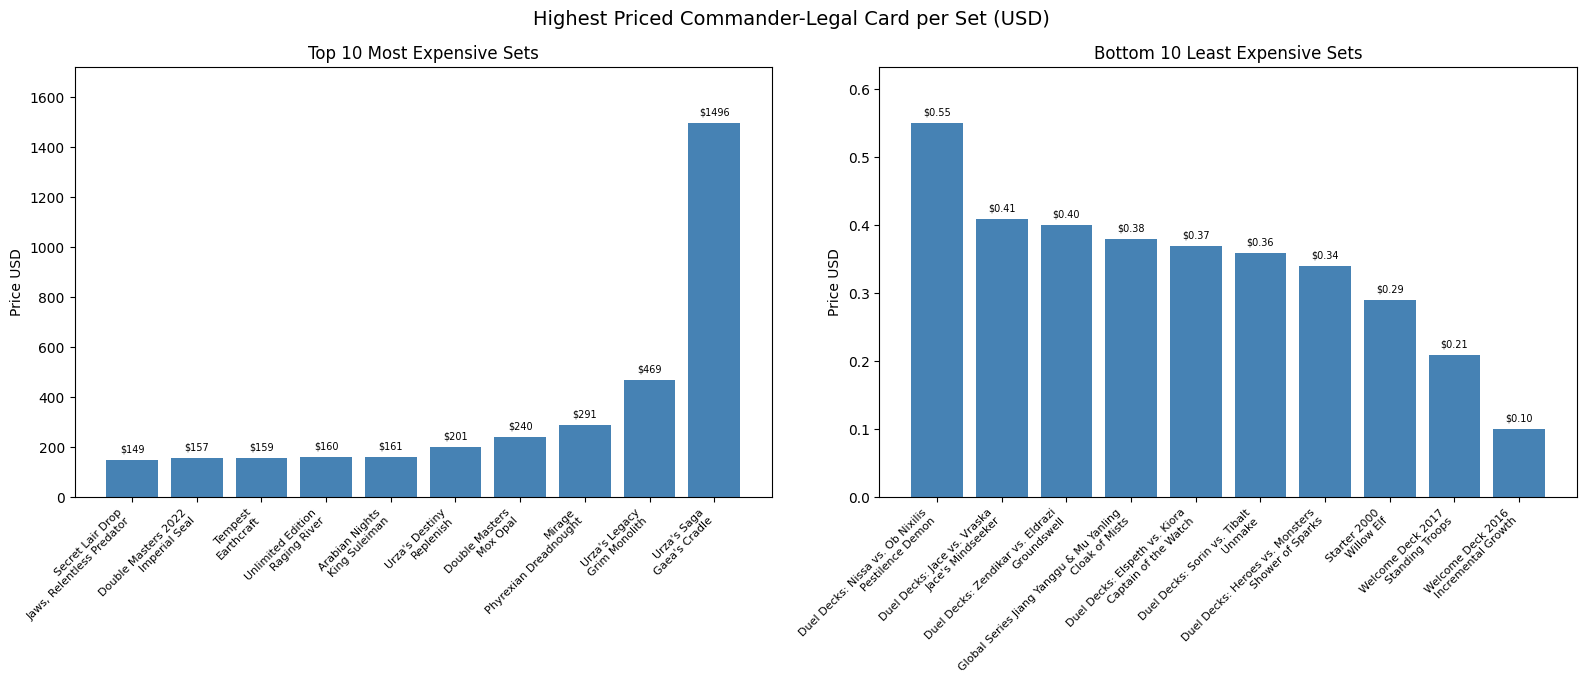

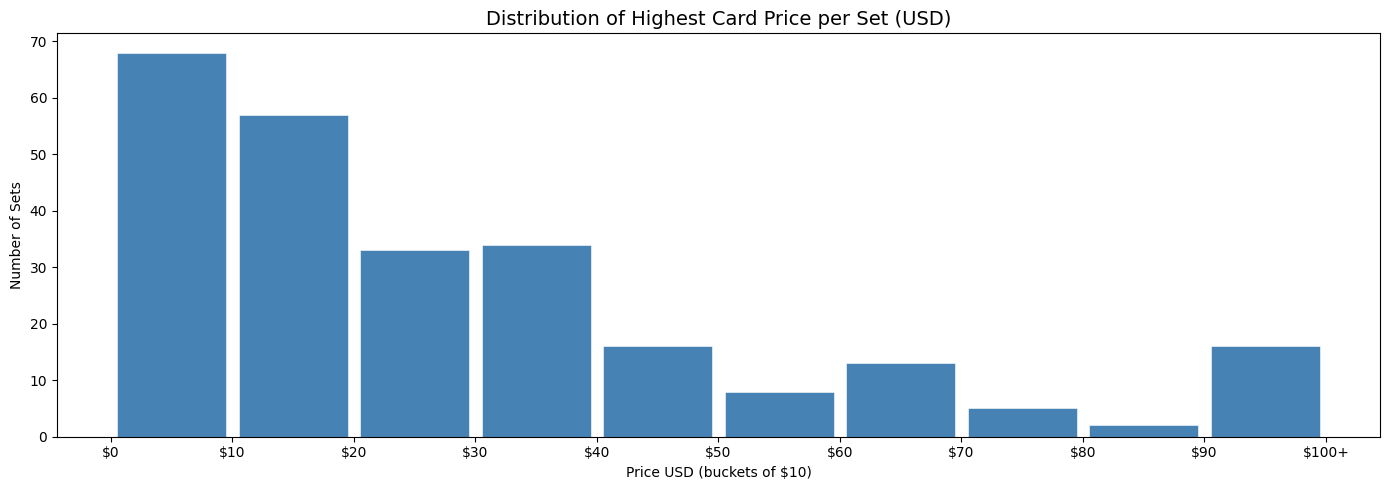

In [6]:
def plot_highest_price_per_set(df: pd.DataFrame, n: int = 10) -> None:
    price_col = 'price_usd'
    s = df.dropna(subset=[price_col, 'set_name', 'name']).copy()
    if 'legal_commander' in s.columns:
        s = s[s['legal_commander']]

    # Highest priced card per set
    idx = s.groupby('set')[price_col].idxmax()
    top = (s.loc[idx][['set', 'set_name', 'name', price_col]]
             .sort_values(price_col, ascending=False)
             .reset_index(drop=True))

    top10 = top.head(n).sort_values(price_col)
    bot10 = top.tail(n).sort_values(price_col, ascending=False)

    def _bar_chart(ax, data, title):
        labels = data.apply(lambda r: f"{r['set_name']}\n{r['name']}", axis=1)
        bars = ax.bar(range(len(data)), data[price_col], color='steelblue')
        ax.set_xticks(range(len(data)))
        ax.set_xticklabels(labels, fontsize=8)
        bar_labels = [f"${v:.0f}" if v >= 10 else f"${v:.2f}" for v in data[price_col]]
        ax.bar_label(bars, labels=bar_labels, padding=4, fontsize=7)
        ax.set_ylabel('Price USD')
        ax.set_title(title, fontsize=12)
        ax.margins(y=0.15)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    _bar_chart(ax1, top10, f'Top {n} Most Expensive Sets')
    _bar_chart(ax2, bot10, f'Bottom {n} Least Expensive Sets')
    plt.suptitle('Highest Priced Commander-Legal Card per Set (USD)', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Histogram with $10 buckets, last bucket = $100+
    bins = list(range(0, 110, 10))  # [0, 10, 20, ..., 100]
    capped = top[price_col].clip(upper=99.99)

    fig, ax = plt.subplots(figsize=(14, 5))
    capped.hist(ax=ax, bins=bins, color='steelblue', edgecolor='white', linewidth=0.4, rwidth=0.9)
    ax.set_xticks(bins)
    ax.set_xticklabels([f'${b}' if b < 100 else '$100+' for b in bins])
    ax.set_title('Distribution of Highest Card Price per Set (USD)', fontsize=14)
    ax.set_xlabel('Price USD (buckets of $10)')
    ax.set_ylabel('Number of Sets')
    ax.yaxis.set_major_locator(plt.MultipleLocator(10))
    ax.grid(False)
    plt.tight_layout()
    plt.show()

plot_highest_price_per_set(cards_df)